<a href="https://colab.research.google.com/github/KKarenOtta/Modelo-de-previs-o-patol-gica/blob/main/Estatistica_CP04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Fixar seed para reprodutibilidade dos dados sintéticos criados
np.random.seed(42)
n = 500  # número de pacientes

# Gerar variáveis clínicas sintéticas
dados = pd.DataFrame({
    'idade': np.random.normal(55, 12, n).clip(18, 90),
    'glicose': np.random.normal(110, 25, n).clip(60, 300),
    'pressao': np.random.normal(130, 20, n).clip(80, 200),
    'imc': np.random.normal(27, 5, n).clip(15, 50),
    'colesterol': np.random.normal(200, 40, n).clip(100, 400),
    'tabagismo': np.random.binomial(1, 0.3, n),
})

# Score deprobabilidade
score = (
    0.03 * (dados["idade"] - 50) +
    0.04 * (dados["glicose"] - 100) +
    0.03 * (dados["pressao"] - 120) +
    0.06 * (dados["imc"] - 25) +
    0.01 * (dados["colesterol"] - 180) +
    0.40 * dados["tabagismo"]
)

# Sigmoid para virar probabilidade (0..1)
prob = 1 / (1 + np.exp(-score))

# Amostra Bernoulli com essa probabilidade => risco não é determinístico
dados["risco"] = (np.random.rand(n) < prob).astype(int)

print("Distribuição de risco:", dados["risco"].value_counts().to_dict())

Distribuição de risco: {1: 386, 0: 114}


#Visualização: Histogramas e Box-Plots


/tmp/ipykernel_353/474759861.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risco', y='glicose', data=dados, ax=axes[1][2], palette='Set2')
/tmp/ipykernel_353/474759861.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1][2].set_xticklabels(['Sem Risco', 'Com Risco'])


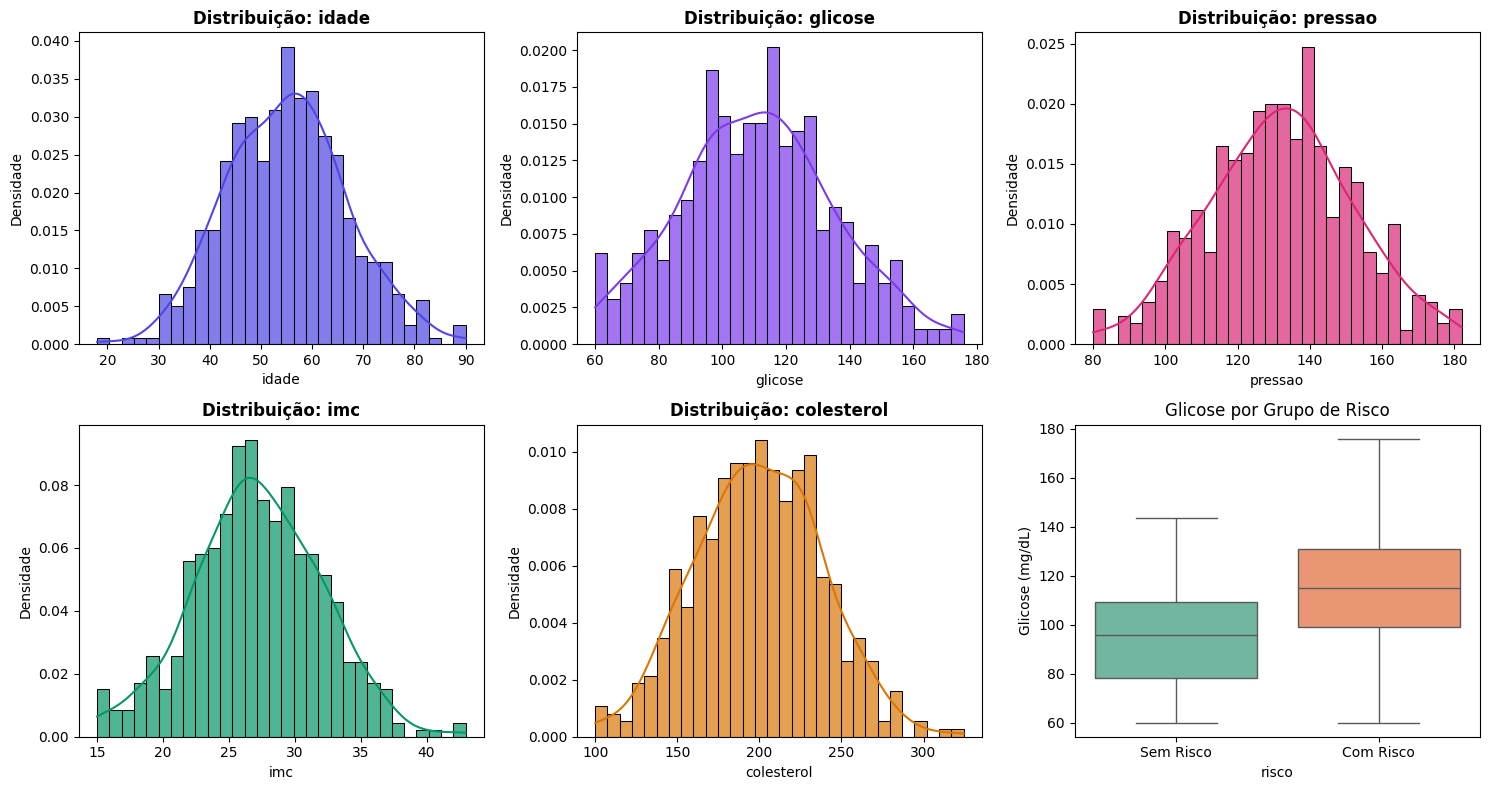

In [ ]:
# Visualização: Histogramas e Box-Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
variaveis = ['idade', 'glicose', 'pressao', 'imc', 'colesterol']
cores = ['#4F46E5', '#7C3AED', '#DB2777', '#059669', '#D97706']

# Histogramas com curva KDE
for i, (var, cor) in enumerate(zip(variaveis, cores)):
    ax = axes[i // 3][i % 3]
    sns.histplot(dados[var], bins=30, ax=ax, color=cor, kde=True, stat="density", alpha=0.7)
    ax.set_title(f'Distribuição: {var}', fontsize=12, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Densidade')

# Box-plot com parativo por grupo de risco
sns.boxplot(x='risco', y='glicose', data=dados, ax=axes[1][2], palette='Set2')
axes[1][2].set_title('Glicose por Grupo de Risco')
axes[1][2].set_xticklabels(['Sem Risco', 'Com Risco'])
axes[1][2].set_ylabel('Glicose (mg/dL)')

plt.tight_layout()
plt.savefig('distribuicoes_clinicas.png', dpi=150)
plt.show()

#Modelo Random Forest para Previsão de Risco


CV (média):
  acc  (train/test): 0.831 / 0.736
  f1   (train/test): 0.884 / 0.82
  auc  (train/test): 0.915 / 0.776

OOB score: 0.754

Relatório (teste):
              precision    recall  f1-score   support

   Sem Risco       0.48      0.65      0.55        34
   Com Risco       0.88      0.79      0.84       116

    accuracy                           0.76       150
   macro avg       0.68      0.72      0.69       150
weighted avg       0.79      0.76      0.77       150



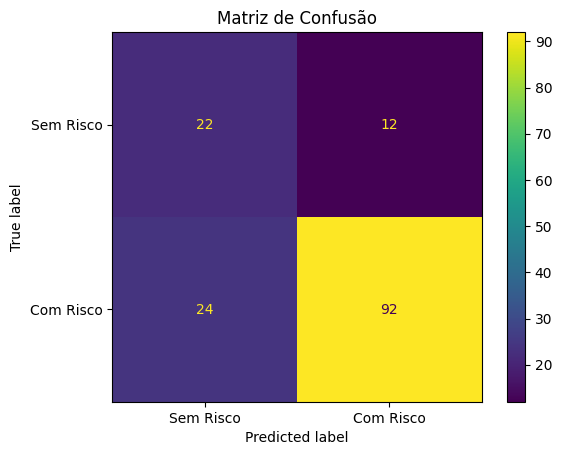

Acurácia: 0.7600
Precisão: 0.8846
Sensibilidade: 0.7931
Especificidade: 0.6471

Importância das variáveis:
glicose       0.451
pressao       0.194
colesterol    0.137
idade         0.125
imc           0.086
tabagismo     0.007
dtype: float64


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score

# Divisão treino/teste
X = dados.drop(columns=["risco"])
y = dados["risco"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Random Forest
modelo = RandomForestClassifier(
    n_estimators=400,
    max_depth=4,             # limita complexidade
    min_samples_split=20,    # evita splits “fáceis”
    min_samples_leaf=10,     # folhas maiores generalizam melhor
    max_features="sqrt",     # reduz correlação entre árvores
    bootstrap=True,
    oob_score=True,          # validação out-of-bag (ajuda a detectar overfit)
    random_state=42,
    class_weight="balanced_subsample"
)

# Validação cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    modelo, X, y,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=True
)

print("\nCV (média):")
print("  acc  (train/test):", scores["train_accuracy"].mean().round(3), "/", scores["test_accuracy"].mean().round(3))
print("  f1   (train/test):", scores["train_f1"].mean().round(3), "/", scores["test_f1"].mean().round(3))
print("  auc  (train/test):", scores["train_roc_auc"].mean().round(3), "/", scores["test_roc_auc"].mean().round(3))

# Treinamento do modelo e avaliação
modelo.fit(X_train, y_train)
print("\nOOB score:", round(modelo.oob_score_, 3))

y_pred = modelo.predict(X_test)
print("\nRelatório (teste):")
print(classification_report(y_test, y_pred, target_names=["Sem Risco", "Com Risco"]))

ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, display_labels=["Sem Risco", "Com Risco"])
plt.title("Matriz de Confusão")
plt.show()

# Calculate TN, FP, FN, TP from confusion matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

In [ ]:
# Acurácia, Precision
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
specificity = TN / (TN + FP)
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Sensibilidade: {recall:.4f}")
print(f"Especificidade: {specificity:.4f}")


# Importância das variáveis
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
importancias = importancias.round(3)
print("\nImportância das variáveis:")
print(importancias)

Acurácia: 0.7600
Precisão: 0.8846
Sensibilidade: 0.7931
Especificidade: 0.6471

Importância das variáveis:
glicose       0.451
pressao       0.194
colesterol    0.137
idade         0.125
imc           0.086
tabagismo     0.007
dtype: float64


OBS: matriz de confusão para visualizar o desempenho do modelo em termos de verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos.

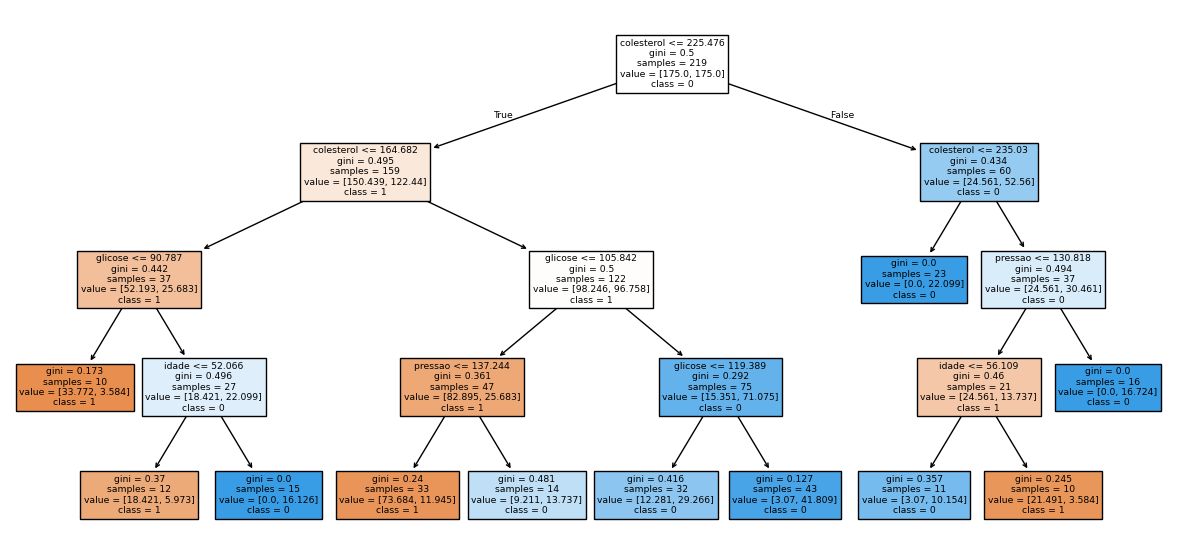

In [ ]:
from sklearn.tree import plot_tree

# Acessar a primeira arvore da floresta
primeira_arvore = modelo.estimators_[10]

# Plotar a árvore
plt.figure(figsize=(15, 7))
plot_tree(primeira_arvore, feature_names=X.columns, class_names=[str(c) for c in y.unique()], filled=True)
plt.show()